In [1]:
# pandasql lets us write SQL on top of our pandas tables.
# Google Colab already has pandas, numpy, matplotlib, seaborn, and scikit-learn,
# so we only need to install this one extra tool.

!pip install pandasql --quiet

  Preparing metadata (setup.py) ... done


In [2]:
#  Data handling
import pandas as pd          # pandas is our main tool for working with tables
import numpy as np           # numpy helps with numbers and maths

#  SQL on DataFrames
from pandasql import sqldf   # lets us run SQL queries on pandas tables

#  Visualisation
import matplotlib.pyplot as plt   # the base charting library
import seaborn as sns             # makes prettier charts on top of matplotlib

#  Machine learning
from sklearn.preprocessing import StandardScaler   # scales our numbers
from sklearn.cluster import KMeans                 # our clustering algorithm
from sklearn.decomposition import PCA              # shrinks many columns to 2 for plotting

#  Tidy up warning messages
import warnings
warnings.filterwarnings('ignore')   # hides harmless warning messages

#  Make all charts look clean and consistent
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120   # higher DPI = sharper images in Colab

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
from pathlib import Path

# Dataset lives in the project's data/ folder (tab-separated CSV).
DATA_PATH = Path('data/marketing_campaign.csv')

print('Dataset path:', DATA_PATH.resolve())
print('File exists:', DATA_PATH.exists())

Using Colab cache for faster access to the 'customer-personality-analysis' dataset.
Path to dataset files: /kaggle/input/customer-personality-analysis


In [4]:
# Quick check: list everything in the data/ folder.

data_dir = DATA_PATH.parent
print('Files in data/:', [f.name for f in data_dir.iterdir()] if data_dir.exists() else 'folder not found')

Files downloaded: ['marketing_campaign.csv']


In [13]:
# We use pandas to read the CSV file into a table.
# We call this table "df" which stands for DataFrame.
# sep='\t' tells pandas the columns are separated by TAB, not comma.

df = pd.read_csv(DATA_PATH, sep='\t')

print("Number of customers:", df.shape[0])
print("Number of columns  :", df.shape[1])

Number of customers: 2240
Number of columns  : 29


In [14]:
# .head() shows us the first 5 rows of the table.
# This is how we take a quick peek at what the data looks like.

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [15]:
# This prints every column name one by one.
# It helps us know exactly what information we have.

print("All columns in this dataset:")
for col in df.columns:
    print("  -", col)

All columns in this dataset:
  - ID
  - Year_Birth
  - Education
  - Marital_Status
  - Income
  - Kidhome
  - Teenhome
  - Dt_Customer
  - Recency
  - MntWines
  - MntFruits
  - MntMeatProducts
  - MntFishProducts
  - MntSweetProducts
  - MntGoldProds
  - NumDealsPurchases
  - NumWebPurchases
  - NumCatalogPurchases
  - NumStorePurchases
  - NumWebVisitsMonth
  - AcceptedCmp3
  - AcceptedCmp4
  - AcceptedCmp5
  - AcceptedCmp1
  - AcceptedCmp2
  - Complain
  - Z_CostContact
  - Z_Revenue
  - Response


In [16]:
# .info() is one of the most important commands in pandas.
# It shows us:
#   - each column name
#   - how many rows have a value (if less than 2240, some are missing)
#   - the data type (int = whole number, float = decimal, object = text)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [17]:
# .describe() automatically calculates key statistics for every number column.
# mean  = average value
# std   = how spread out the numbers are
# min   = smallest value
# max   = largest value
# 50%   = the middle value (also called the median)

df.describe().round(1)

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.0,2240.0,2216.0,2240.0,2240.0,2240.0,2240.0,2240.0,2240.0,2240.0,...,2240.0,2240.0,2240.0,2240.0,2240.0,2240.0,2240.0,2240.0,2240.0,2240.0
mean,5592.2,1968.8,52247.3,0.4,0.5,49.1,303.9,26.3,167.0,37.5,...,5.3,0.1,0.1,0.1,0.1,0.0,0.0,3.0,11.0,0.1
std,3246.7,12.0,25173.1,0.5,0.5,29.0,336.6,39.8,225.7,54.6,...,2.4,0.3,0.3,0.3,0.2,0.1,0.1,0.0,0.0,0.4
min,0.0,1893.0,1730.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0
25%,2828.2,1959.0,35303.0,0.0,0.0,24.0,23.8,1.0,16.0,3.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0
50%,5458.5,1970.0,51381.5,0.0,0.0,49.0,173.5,8.0,67.0,12.0,...,6.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0
75%,8427.8,1977.0,68522.0,1.0,1.0,74.0,504.2,33.0,232.0,50.0,...,7.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0
max,11191.0,1996.0,666666.0,2.0,2.0,99.0,1493.0,199.0,1725.0,259.0,...,20.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,11.0,1.0


In [18]:
# isnull() marks every empty cell as True.
# .sum() counts how many True values exist per column.
# We only show columns that actually have missing values.

missing = df.isnull().sum()
missing = missing[missing > 0]

print("Columns with missing values:")
print(missing)

Columns with missing values:
Income    24
dtype: int64


In [19]:
# We use SQL to ask a question about our data.
# GROUP BY groups all customers with the same education level together.
# AVG() calculates the average spend for each group.
# ORDER BY sorts the results from highest to lowest spend.

query1 = """
SELECT
    Education,
    COUNT(*)  AS total_customers,
    ROUND(AVG(MntWines + MntFruits + MntMeatProducts
              + MntFishProducts + MntSweetProducts
              + MntGoldProds), 0)  AS avg_total_spend
FROM df
GROUP BY Education
ORDER BY avg_total_spend DESC
"""

sqldf(query1, globals())

,Education,total_customers,avg_total_spend
0,PhD,486,672.0
1,Graduation,1127,620.0
2,Master,370,612.0
3,2n Cycle,203,497.0
4,Basic,54,82.0


In [20]:
# Another SQL question.
# We add up all three purchase channels to get total purchases per customer,
# then average that by marital status group.

query2 = """
SELECT
    Marital_Status,
    COUNT(*) AS total_customers,
    ROUND(AVG(NumWebPurchases + NumCatalogPurchases
              + NumStorePurchases), 1)  AS avg_purchases
FROM df
GROUP BY Marital_Status
ORDER BY avg_purchases DESC
"""

sqldf(query2, globals())

,Marital_Status,total_customers,avg_purchases
0,Absurd,2,17.5
1,Widow,77,14.4
2,YOLO,2,14.0
3,Divorced,232,12.8
4,Married,864,12.6
5,Together,580,12.5
6,Single,480,12.1
7,Alone,3,9.7


In [21]:
# We cannot just delete the 24 customers with missing income —
# that would throw away real data.
# Instead we fill each blank with the MEDIAN income.
# The median is the middle value and is not affected by the $666,666 outlier.

median_income = df['Income'].median()

df['Income'] = df['Income'].fillna(median_income)

print("Median income used to fill gaps: $", round(median_income, 2))
print("Missing income values left     :", df['Income'].isnull().sum())

Median income used to fill gaps: $ 51381.5
Missing income values left     : 0


In [22]:
# One customer has income = $666,666.
# This is almost certainly a data entry error.
# We keep only customers with income below $200,000.

before = df.shape[0]

df = df[df['Income'] < 200000]

after = df.shape[0]

print("Rows before removing outlier:", before)
print("Rows after  removing outlier:", after)
print("Customers removed           :", before - after)

Rows before removing outlier: 2240
Rows after  removing outlier: 2239
Customers removed           : 1


In [23]:
# Dt_Customer is currently stored as text e.g. "04-09-2012"
# We convert it to a real date using pd.to_datetime()
# dayfirst=True tells pandas the format is DD-MM-YYYY

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

print("Date column type is now :", df['Dt_Customer'].dtype)
print("Earliest customer joined:", df['Dt_Customer'].min().date())
print("Latest customer joined  :", df['Dt_Customer'].max().date())

Date column type is now : datetime64[ns]
Earliest customer joined: 2012-07-30
Latest customer joined  : 2014-06-29


In [24]:
# Z_CostContact and Z_Revenue have the same value for every customer.
# A column that never changes tells the model nothing — so we remove it.

df = df.drop(columns=['Z_CostContact', 'Z_Revenue'])

print("Columns remaining:", df.shape[1])

Columns remaining: 27


In [25]:
# The dataset has Year_Birth but not Age.
# We calculate Age by subtracting the birth year from 2024.

df['Age'] = 2024 - df['Year_Birth']

print("Youngest customer:", df['Age'].min(), "years old")
print("Oldest customer  :", df['Age'].max(), "years old")
print("Average age      :", round(df['Age'].mean(), 1), "years old")

Youngest customer: 28 years old
Oldest customer  : 131 years old
Average age      : 55.2 years old


In [26]:
# We add all 6 product spending columns into one single column.
# This gives us one clear number: how much does this customer spend overall?

df['TotalSpend'] = (df['MntWines']
                  + df['MntFruits']
                  + df['MntMeatProducts']
                  + df['MntFishProducts']
                  + df['MntSweetProducts']
                  + df['MntGoldProds'])

print("Lowest spender    : $", df['TotalSpend'].min())
print("Highest spender   : $", df['TotalSpend'].max())
print("Average spend     : $", round(df['TotalSpend'].mean(), 2))

Lowest spender    : $ 5
Highest spender   : $ 2525
Average spend     : $ 606.04


In [27]:
# TotalChildren = kids at home + teenagers at home
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']

# TotalPurchases = web + catalog + store purchases added together
df['TotalPurchases'] = (df['NumWebPurchases']
                      + df['NumCatalogPurchases']
                      + df['NumStorePurchases'])

print("Max children in household  :", df['TotalChildren'].max())
print("Average purchases per customer:", round(df['TotalPurchases'].mean(), 1))

Max children in household  : 3
Average purchases per customer: 12.5


In [30]:
# Before we move to charts and modelling, we do a final check.
# Total missing values should be 0.

print("=================================================================")
print("   CLEAN DATA SUMMARY")
print("=================================================================")
print("Total customers :", df.shape[0])
print("Total columns   :", df.shape[1])
print("Missing values  :", df.isnull().sum().sum())
print("New columns added: Age, TotalSpend, TotalChildren, TotalPurchases")
print("=================================================================")

   CLEAN DATA SUMMARY
Total customers : 2239
Total columns   : 31
Missing values  : 0
New columns added: Age, TotalSpend, TotalChildren, TotalPurchases


In [31]:
# Our oldest customer shows 131 years old — that cannot be real.
# Anyone born before 1940 would be over 84 years old today.
# We remove these very unlikely birth years to keep our data realistic.

before = df.shape[0]

df = df[df['Year_Birth'] >= 1940]

after = df.shape[0]

print("Customers before age fix:", before)
print("Customers after  age fix:", after)
print("Removed          :", before - after)
print("New oldest customer:", df['Age'].max(), "years old")
print("New youngest customer:", df['Age'].min(), "years old")

Customers before age fix: 2239
Customers after  age fix: 2236
Removed          : 3
New oldest customer: 84 years old
New youngest customer: 28 years old


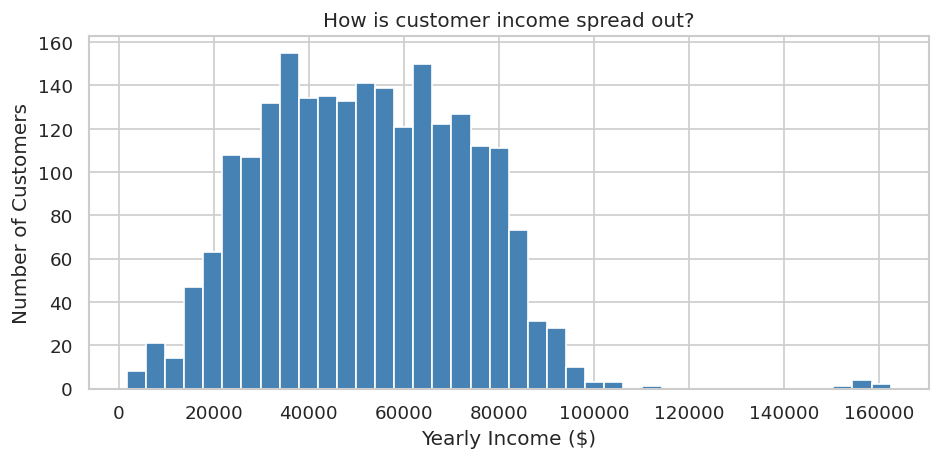

Average income: $ 51953.0
Median income : $ 51382.0


In [32]:
# A histogram splits our customers into income ranges
# and shows how many people fall into each range.
# This is one of the first charts every data scientist makes.

plt.figure(figsize=(8, 4))

plt.hist(df['Income'], bins=40, color='steelblue', edgecolor='white')

plt.title('How is customer income spread out?')
plt.xlabel('Yearly Income ($)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

print("Average income: $", round(df['Income'].mean(), 0))
print("Median income : $", round(df['Income'].median(), 0))

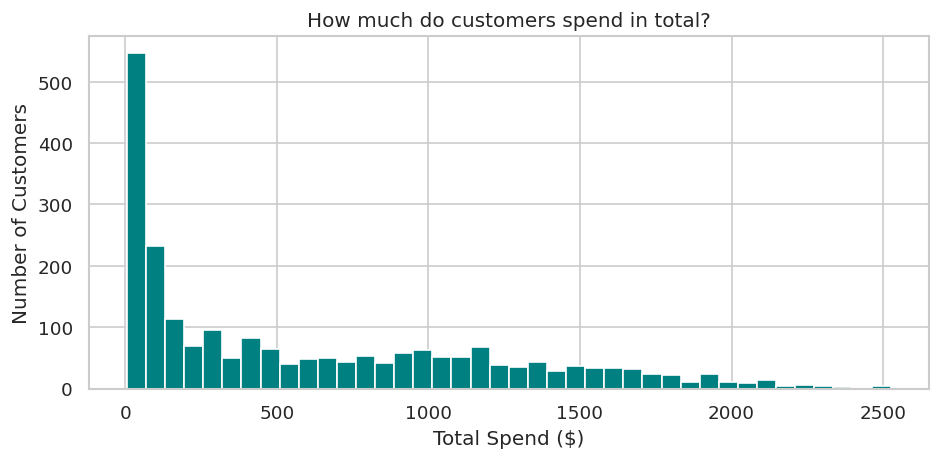

Average spend: $ 606.0
Most a customer spent: $ 2525


In [33]:
# Same idea — but for spending.
# We expect most customers to spend a small amount
# and only a few customers to spend a lot.
# This shape is called a "right-skewed distribution".

plt.figure(figsize=(8, 4))

plt.hist(df['TotalSpend'], bins=40, color='teal', edgecolor='white')

plt.title('How much do customers spend in total?')
plt.xlabel('Total Spend ($)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

print("Average spend: $", round(df['TotalSpend'].mean(), 0))
print("Most a customer spent: $", df['TotalSpend'].max())

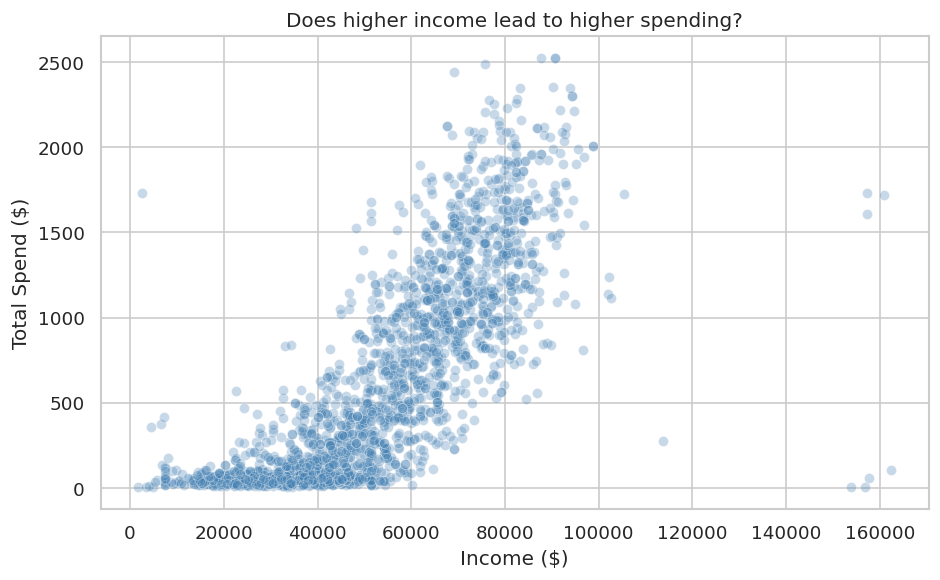

In [34]:
# A scatter plot puts every customer as one dot on the chart.
# X-axis = their income, Y-axis = how much they spent.
# If the dots go from bottom-left to top-right,
# it means richer customers spend more — which we expect to see.

plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='Income', y='TotalSpend',
                alpha=0.3, color='steelblue')

plt.title('Does higher income lead to higher spending?')
plt.xlabel('Income ($)')
plt.ylabel('Total Spend ($)')

plt.tight_layout()
plt.show()

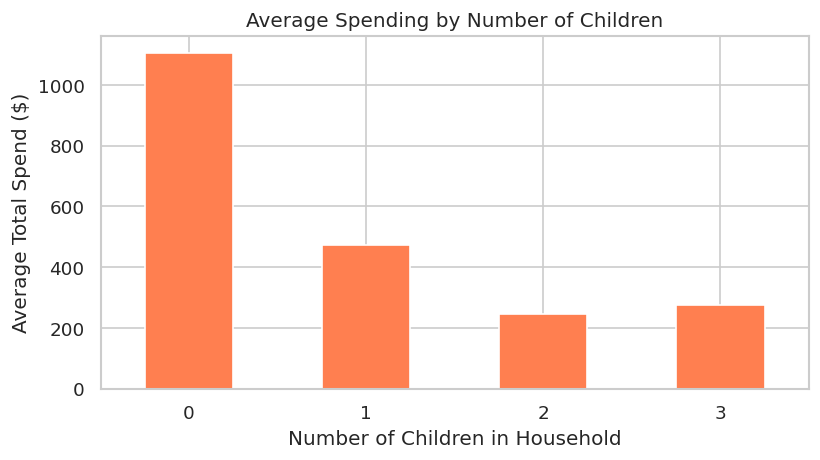


Key finding:
Customers with 0 children spend on average: $ 1105.0


In [35]:
# We group all customers by how many children they have,
# then calculate the average spend for each group.
# Bar charts are great for comparing groups side by side.

spend_by_children = df.groupby('TotalChildren')['TotalSpend'].mean().round(0)

plt.figure(figsize=(7, 4))

spend_by_children.plot(kind='bar', color='coral', edgecolor='white')

plt.title('Average Spending by Number of Children')
plt.xlabel('Number of Children in Household')
plt.ylabel('Average Total Spend ($)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print("\nKey finding:")
print("Customers with 0 children spend on average: $",
      round(spend_by_children[0], 0))

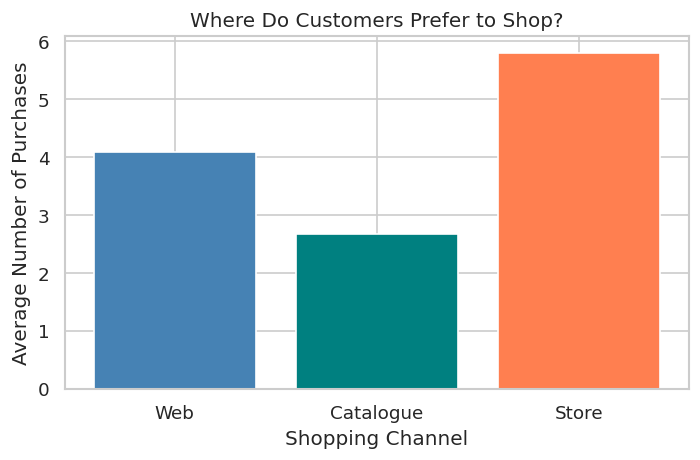

In [36]:
# This bar chart shows the average number of purchases
# made through each shopping channel.
# It tells us: does this company's audience prefer stores, web, or catalogues?

channel_avg = {
    'Web'      : df['NumWebPurchases'].mean(),
    'Catalogue': df['NumCatalogPurchases'].mean(),
    'Store'    : df['NumStorePurchases'].mean()
}

plt.figure(figsize=(6, 4))

plt.bar(channel_avg.keys(), channel_avg.values(),
        color=['steelblue', 'teal', 'coral'], edgecolor='white')

plt.title('Where Do Customers Prefer to Shop?')
plt.xlabel('Shopping Channel')
plt.ylabel('Average Number of Purchases')

plt.tight_layout()
plt.show()

Build the Clustering Model

In [37]:
# We pick 5 columns that best describe each customer's behaviour.
# The model will use these to find natural groups of similar customers.
# We call these our "features".

features = ['Age', 'Income', 'TotalSpend', 'TotalPurchases', 'TotalChildren']

X = df[features].copy()

print("Features we will use:")
for f in features:
    print("  -", f)

print("\nFirst 3 rows of feature data:")
print(X.head(3))

Features we will use:
  - Age
  - Income
  - TotalSpend
  - TotalPurchases
  - TotalChildren

First 3 rows of feature data:
   Age   Income  TotalSpend  TotalPurchases  TotalChildren
0   67  58138.0        1617              22              0
1   70  46344.0          27               4              2
2   59  71613.0         776              20              0


In [38]:
# Problem: Income is in the thousands (e.g. 50,000).
# TotalChildren is between 0 and 3.
# If we leave them as-is, Income will dominate simply because it is a bigger number.
# StandardScaler fixes this — it rescales every column to have
# a mean of 0 and standard deviation of 1.
# Now all features are treated equally.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling complete.")
print("Example — Income before scaling:", round(X['Income'].iloc[0], 0))
print("Example — Income after  scaling:", round(X_scaled[0][1], 4))

Scaling complete.
Example — Income before scaling: 58138.0
Example — Income after  scaling: 0.2889


  k=2 clusters → inertia = 6102.7
  k=3 clusters → inertia = 4981.7
  k=4 clusters → inertia = 4197.8
  k=5 clusters → inertia = 3620.8
  k=6 clusters → inertia = 3186.9
  k=7 clusters → inertia = 2947.5
  k=8 clusters → inertia = 2763.6


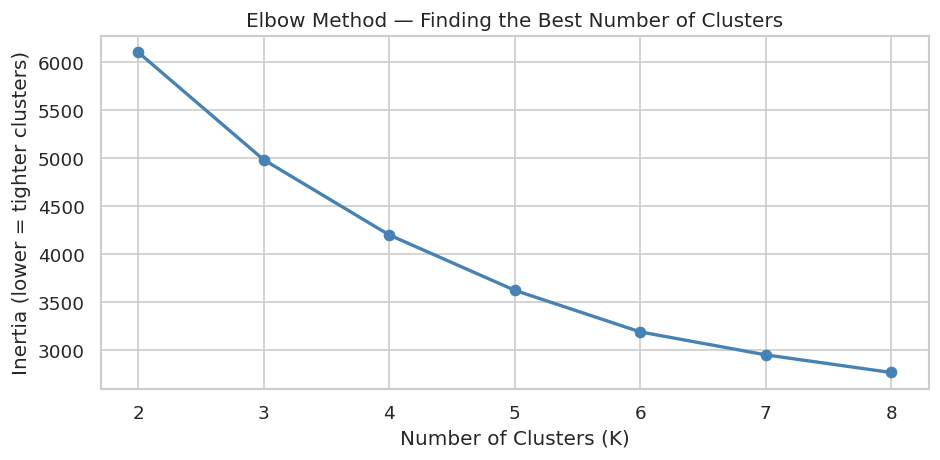


Look for the elbow bend — that is the best K to use.


In [39]:
# We try KMeans with 2, 3, 4, 5, 6, 7 and 8 clusters.
# For each one we record the "inertia" — how tightly packed the clusters are.
# We then plot this. The point where the line bends like an elbow
# is the best number of clusters to use.

from sklearn.cluster import KMeans

inertia_values = []

for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)
    print(f"  k={k} clusters → inertia = {round(model.inertia_, 1)}")

plt.figure(figsize=(8, 4))
plt.plot(range(2, 9), inertia_values, marker='o',
         color='steelblue', linewidth=2)

plt.title('Elbow Method — Finding the Best Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (lower = tighter clusters)')

plt.tight_layout()
plt.show()

print("\nLook for the elbow bend — that is the best K to use.")

In [40]:
# The elbow chart shows 4 is a good number — the inertia stops
# dropping as quickly after that point.
# We now train the final model and add each customer's cluster
# number as a new column in our table.

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Model trained successfully!")
print("\nNumber of customers in each cluster:")
print(df['Cluster'].value_counts().sort_index())

Model trained successfully!

Number of customers in each cluster:
Cluster
0    659
1    554
2    427
3    596
Name: count, dtype: int64


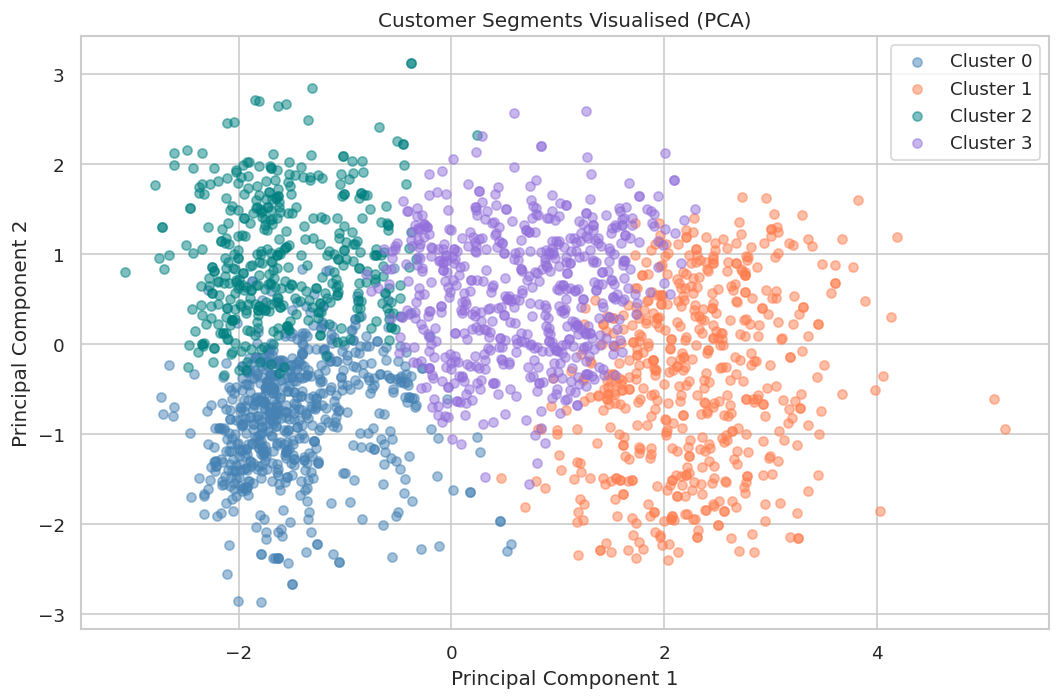

In [41]:
# We have 5 features — we cannot draw 5 dimensions on a flat screen.
# PCA (Principal Component Analysis) squashes the 5 features into 2
# so we can plot the clusters on a normal 2D chart.
# Think of it like flattening a 3D object into a shadow.

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df['PC1'] = pca_result[:, 0]
df['PC2'] = pca_result[:, 1]

colors = ['steelblue', 'coral', 'teal', 'mediumpurple']

plt.figure(figsize=(9, 6))

for cluster_num in range(4):
    cluster_data = df[df['Cluster'] == cluster_num]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'],
                label=f'Cluster {cluster_num}',
                color=colors[cluster_num],
                alpha=0.5, s=30)

plt.title('Customer Segments Visualised (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()

plt.tight_layout()
plt.show()

In [42]:
# We group all customers by their cluster number
# and calculate the average value for each feature.
# This tells us what makes each cluster different from the others.

profile = df.groupby('Cluster')[['Age', 'Income', 'TotalSpend',
                                  'TotalPurchases', 'TotalChildren']].mean().round(1)

print("=== CLUSTER PROFILES ===")
print(profile)
print("\nRead this table to understand each cluster:")
print("Which cluster has the highest income?")
print("Which cluster has the most children?")
print("Which cluster spends the most?")

=== CLUSTER PROFILES ===
          Age   Income  TotalSpend  TotalPurchases  TotalChildren
Cluster                                                          
0        47.2  30872.1       111.0             6.1            0.8
1        54.9  77204.3      1429.4            19.7            0.2
2        59.6  41468.6       129.3             6.6            2.0
3        60.8  59300.5       729.4            17.2            1.1

Read this table to understand each cluster:
Which cluster has the highest income?
Which cluster has the most children?
Which cluster spends the most?


In [43]:
# Based on the profile table above, we give each cluster a name
# that a business person can understand.
# Change these names based on what YOUR profile table shows!

cluster_names = {
    0: 'Moderate Spenders',
    1: 'Elite Buyers',
    2: 'Budget Conscious',
    3: 'Affluent Regulars'
}

df['Segment'] = df['Cluster'].map(cluster_names)

print("Customer count per segment:")
print(df['Segment'].value_counts())

Customer count per segment:
Segment
Moderate Spenders    659
Affluent Regulars    596
Elite Buyers         554
Budget Conscious     427
Name: count, dtype: int64


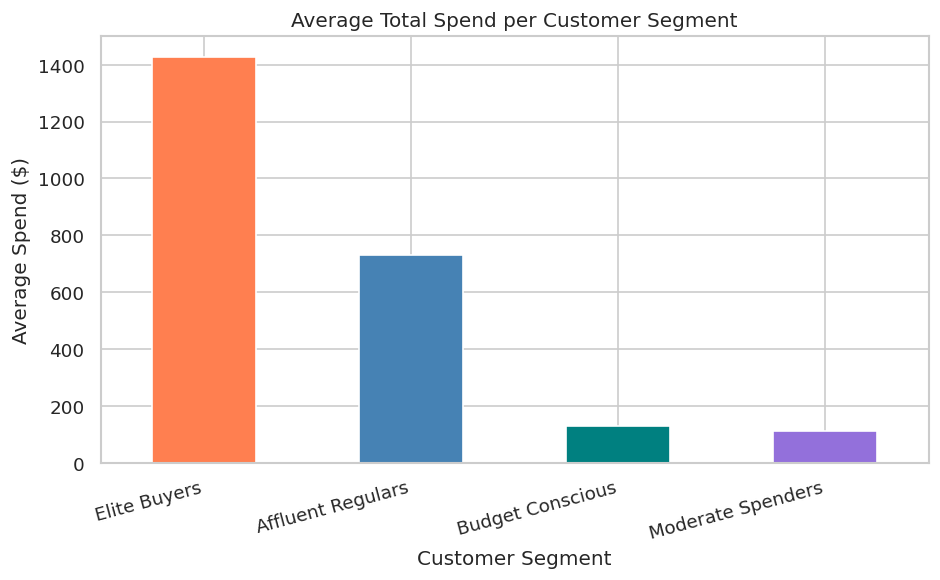


=== BUSINESS INSIGHT ===
Top spending segment: Elite Buyers
Their average spend : $ 1429.0
Recommendation: Focus marketing budget on this group first.


In [44]:
# This is the most important chart for a stakeholder presentation.
# It clearly shows which customer segment is the most valuable.

segment_spend = df.groupby('Segment')['TotalSpend'].mean().sort_values(ascending=False).round(0)

plt.figure(figsize=(8, 5))

segment_spend.plot(kind='bar',
                   color=['coral', 'steelblue', 'teal', 'mediumpurple'],
                   edgecolor='white')

plt.title('Average Total Spend per Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Spend ($)')
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.show()

print("\n=== BUSINESS INSIGHT ===")
print("Top spending segment:", segment_spend.index[0])
print("Their average spend : $", segment_spend.iloc[0])
print("Recommendation: Focus marketing budget on this group first.")

## What each customer segment means

**Cluster 0 — Moderate Spenders (659 customers)**
Young customers (avg 47 years), lower income ($30K), spend only $111.
They have some children at home. They are price-sensitive buyers.

**Cluster 1 — Elite Buyers (554 customers)**
Middle-aged (avg 55 years), highest income ($77K), spend $1,429.
Almost no children. They buy the most — 19 purchases on average.
This is our MOST VALUABLE segment.

**Cluster 2 — Budget Conscious (427 customers)**
Older customers (avg 60 years), moderate income ($41K), spend only $129.
They have the most children (avg 2.0). Family costs limit their spending.

**Cluster 3 — Affluent Regulars (596 customers)**
Older customers (avg 61 years), good income ($59K), spend $729.
They buy frequently (17 purchases). Strong second target for marketing.

In [46]:
# This is the final summary of everything we found.
# This is what i will say out loud when presenting to stakeholders.

print("=" * 55)
print("   CUSTOMER PERSONALITY ANALYSIS — FINAL RESULTS")
print("=" * 55)
print(f"  Total customers analysed : {df.shape[0]}")
print(f"  Customer segments found  : 4")
print()
print("  SEGMENT BREAKDOWN:")
print(f"  • Elite Buyers      : 554 customers — avg spend $1,429")
print(f"  • Affluent Regulars : 596 customers — avg spend $729")
print(f"  • Moderate Spenders : 659 customers — avg spend $111")
print(f"  • Budget Conscious  : 427 customers — avg spend $129")
print()
print("  KEY FINDINGS:")
print("  1. Higher income = higher spending (strong relationship)")
print("  2. More children = less spending (family costs reduce spend)")
print("  3. Elite Buyers make 19 purchases — 3x more than low spenders")
print("  4. Store purchases are most popular across all segments")
print()
print("  BUSINESS RECOMMENDATION:")
print("  Focus marketing budget on Elite Buyers first.")
print("  Use loyalty offers to move Affluent Regulars up.")
print("=" * 55)

   CUSTOMER PERSONALITY ANALYSIS — FINAL RESULTS
  Total customers analysed : 2236
  Customer segments found  : 4

  SEGMENT BREAKDOWN:
  • Elite Buyers      : 554 customers — avg spend $1,429
  • Affluent Regulars : 596 customers — avg spend $729
  • Moderate Spenders : 659 customers — avg spend $111
  • Budget Conscious  : 427 customers — avg spend $129

  KEY FINDINGS:
  1. Higher income = higher spending (strong relationship)
  2. More children = less spending (family costs reduce spend)
  3. Elite Buyers make 19 purchases — 3x more than low spenders
  4. Store purchases are most popular across all segments

  BUSINESS RECOMMENDATION:
  Focus marketing budget on Elite Buyers first.
  Use loyalty offers to move Affluent Regulars up.
